# 06: Final report

Joins the per-record metric CSVs (`02`-`05`) on `(dataset, target, model, query_id, difficulty)`, aggregates per matrix cell, renders figures, and writes `evaluation/reports/final.md`. Execution columns are optional (absent in the deferred first pass).

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "evaluation"))

from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
from eval_harness import OUTPUTS_DIR, REPORTS_DIR, plots

FIG_DIR = REPORTS_DIR / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True); FIG_DIR.mkdir(parents=True, exist_ok=True)
FINAL_MD = REPORTS_DIR / 'final.md'

## Load and join metric CSVs

In [2]:
beh = pd.read_csv(OUTPUTS_DIR / 'metrics_behavioural.csv')
stru = pd.read_csv(OUTPUTS_DIR / 'metrics_structural.csv')
dist = pd.read_csv(OUTPUTS_DIR / 'metrics_distance.csv')
exec_csv = OUTPUTS_DIR / 'metrics_execution.csv'
execm = pd.read_csv(exec_csv) if exec_csv.exists() else None

key = ['dataset','target','model','query_id','difficulty']
df = beh.merge(stru, on=key, how='outer').merge(dist, on=key, how='outer')
if execm is not None:
    exec_key = [k for k in key if k in execm.columns]
    # Only bring in execution-specific columns; drop columns already present
    # (e.g. validation_passed) so the merge does not create _x/_y collisions.
    exec_cols = exec_key + [c for c in execm.columns if c not in df.columns]
    df = df.merge(execm[exec_cols], on=exec_key, how='left')
print(f'Joined rows: {len(df)}')
df.head(5)

Joined rows: 56


,dataset,target,model,provider,query_id,difficulty,validation_passed,pass_at_1,iterations_used,duration_seconds,...,reference_error,translated_runtime_s,execution_error,execution_accuracy,result_precision,result_recall,result_f1,result_jaccard_dist,reference_rows,translated_rows
0,ldbc,cypher,claude-opus-4-8,anthropic,ldbc_q01,easy,True,True,1,2.084392,...,NaN,0.170298,NaN,1.0,1.0,1.0,1.0,0.0,1,1
1,ldbc,cypher,claude-opus-4-8,anthropic,ldbc_q02,easy,True,True,1,7.168288,...,NaN,2.274573,NaN,1.0,1.0,1.0,1.0,0.0,12932,12932
2,ldbc,cypher,claude-opus-4-8,anthropic,ldbc_q03,easy,True,True,1,1.633420,...,NaN,0.156813,NaN,1.0,1.0,1.0,1.0,0.0,4,4
3,ldbc,cypher,claude-opus-4-8,anthropic,ldbc_q04,hard,True,True,1,2.711763,...,NaN,5.566250,NaN,1.0,1.0,1.0,1.0,0.0,10,10
4,ldbc,cypher,claude-opus-4-8,anthropic,ldbc_q05,hard,True,True,1,2.775870,...,NaN,6.745627,NaN,1.0,1.0,1.0,1.0,0.0,20,20


In [3]:
# Shared axes and columns for the model-comparison figures and the report tables.
# Derived from the data (never hardcoded), so 1-4 models and any query id set render.
MODELS = plots.model_axis(df)
QUERIES = plots.query_axis(df)
COMP_COLS = plots.COMPONENT_F1_COLS
print(f'{len(MODELS)} model(s): {MODELS}')
print(f'{len(QUERIES)} query id(s): {QUERIES}')

4 model(s): ['claude-opus-4-8', 'gemma4:26b', 'llama3.2:latest', 'qwen3-coder:30b']
14 query id(s): ['ldbc_q01', 'ldbc_q02', 'ldbc_q03', 'ldbc_q04', 'ldbc_q05', 'ldbc_q06', 'ldbc_q07', 'ldbc_q08', 'ldbc_q09', 'ldbc_q10', 'ldbc_q11', 'ldbc_q12', 'ldbc_q13', 'ldbc_q14']


## Headline numbers per matrix cell

In [4]:
group = ['dataset','target','model']
headline = pd.DataFrame()
headline['validation_pass_rate'] = df.groupby(group)['validation_passed'].mean()
headline['pass@1'] = df.groupby(group)['pass_at_1'].mean()
headline['component_f1'] = df.groupby(group)['component_f1_overall'].mean()
headline['normalized_ted'] = df.groupby(group)['normalized_ted'].mean()
if execm is not None and 'execution_accuracy' in df.columns:
    headline['execution_accuracy'] = df.groupby(group)['execution_accuracy'].mean()
    headline['result_f1'] = df.groupby(group)['result_f1'].mean()
headline

validation_pass_rate    pass@1  component_f1  \
dataset target model                                                           
ldbc    cypher claude-opus-4-8                   1.0  1.000000      0.978990   
               gemma4:26b                        1.0  1.000000      0.980154   
               llama3.2:latest                   1.0  0.857143      0.816617   
               qwen3-coder:30b                   1.0  1.000000      0.925995   

                                normalized_ted  execution_accuracy  result_f1  
dataset target model                                                           
ldbc    cypher claude-opus-4-8        0.070899            1.000000   1.000000  
               gemma4:26b             0.054188            1.000000   1.000000  
               llama3.2:latest        0.401815            0.285714   0.294414  
               qwen3-coder:30b        0.177632            0.714286   0.722986

## Stratified tables

In [5]:
primary = ['validation_passed','pass_at_1','component_f1_overall','normalized_ted']
if execm is not None and 'execution_accuracy' in df.columns:
    primary += ['execution_accuracy','result_f1']
by_cell = df.groupby(group)[primary].mean()
by_diff = df.groupby('difficulty')[primary].mean().reindex(['easy','medium','hard'])
print('By dataset x target x model:'); display(by_cell)
print('By difficulty:'); display(by_diff)

By dataset x target x model:


validation_passed  pass_at_1  \
dataset target model                                           
ldbc    cypher claude-opus-4-8                1.0   1.000000   
               gemma4:26b                     1.0   1.000000   
               llama3.2:latest                1.0   0.857143   
               qwen3-coder:30b                1.0   1.000000   

                                component_f1_overall  normalized_ted  \
dataset target model                                                   
ldbc    cypher claude-opus-4-8              0.978990        0.070899   
               gemma4:26b                   0.980154        0.054188   
               llama3.2:latest              0.816617        0.401815   
               qwen3-coder:30b              0.925995        0.177632   

                                execution_accuracy  result_f1  
dataset target model                                           
ldbc    cypher claude-opus-4-8            1.000000   1.000000  
               gemma4:26b                 1.000000   1.000000  
               llama3.2:latest            0.285714   0.294414  
               qwen3-coder:30b            0.714286   0.722986

By difficulty:


,validation_passed,pass_at_1,component_f1_overall,normalized_ted,execution_accuracy,result_f1
difficulty,,,,,,
easy,1.0,0.916667,0.956282,0.078618,0.833333,0.833333
medium,1.0,1.000000,0.925783,0.238072,0.687500,0.687500
hard,1.0,0.964286,0.912024,0.182533,0.750000,0.758700


## Plots: all models / all queries

Every figure groups by `model` (not `target`), so the models are compared side by side, plus a full query x model matrix for the per-query view. Missing metrics (e.g. execution before notebook 05 runs, or a model run one-at-a-time) show grey `n/a` cells, never a false zero. Figures are written to `reports/figures/` and embedded in `final.md`.

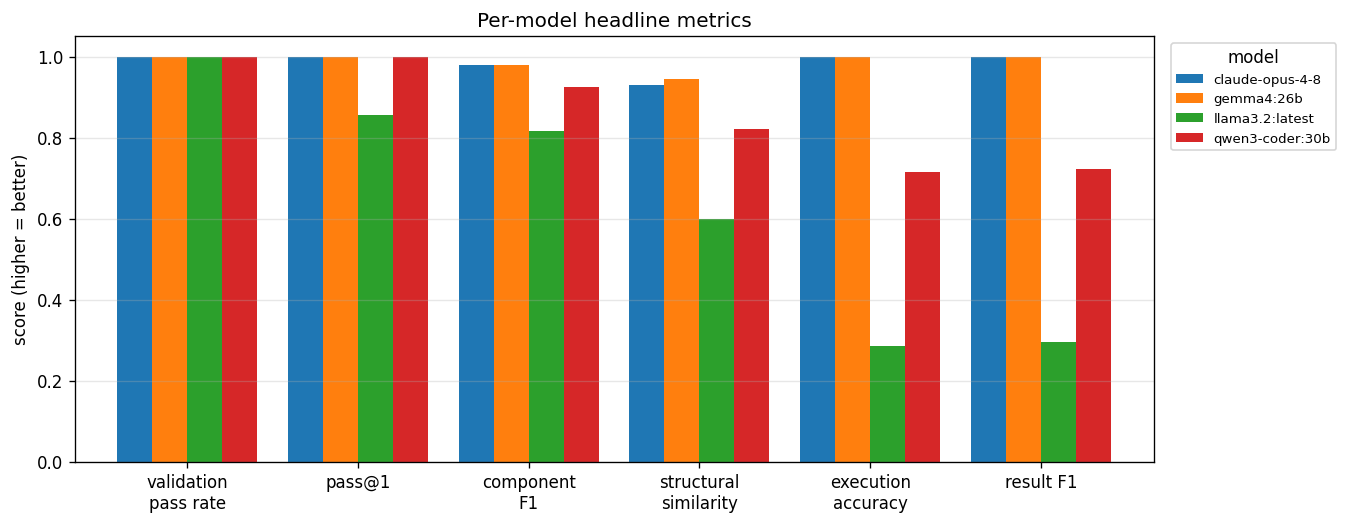

In [6]:
# Primary comparison: the headline "higher = better" metrics, per model.
p = FIG_DIR / 'model_headline.png'
plots.headline_bars(df, p); plots.show(p)

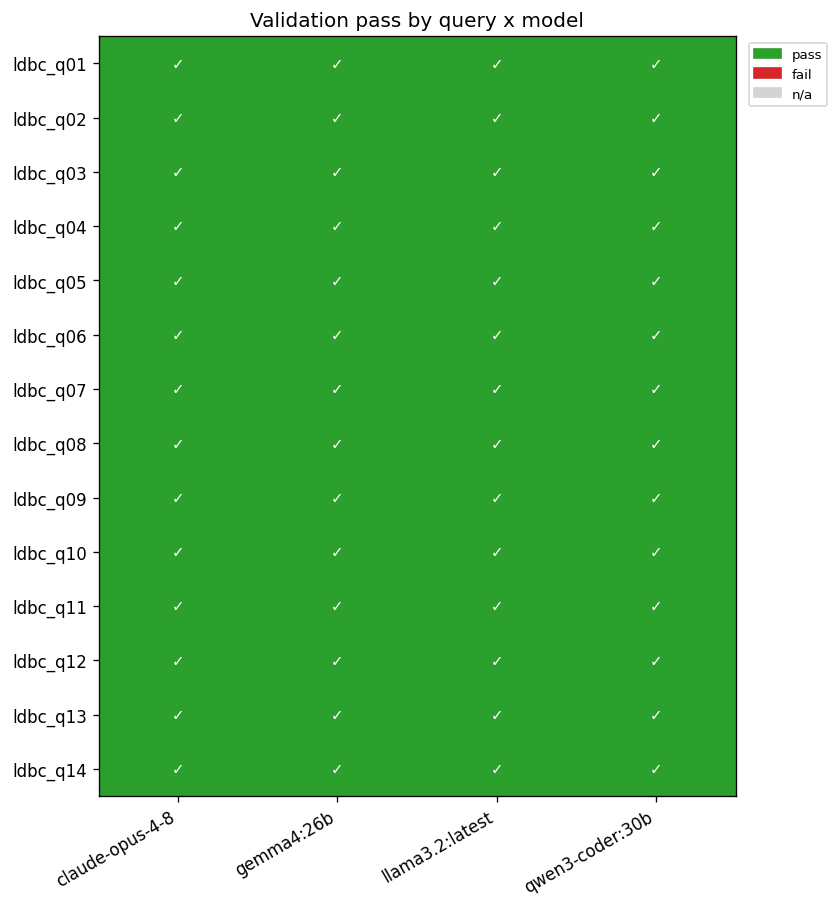

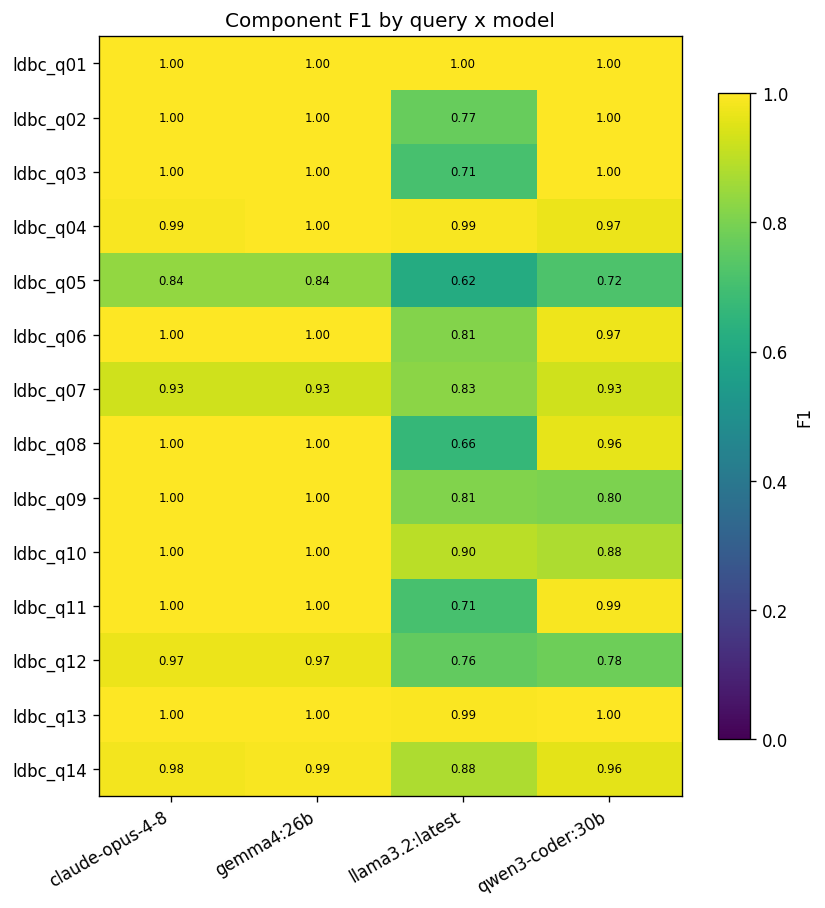

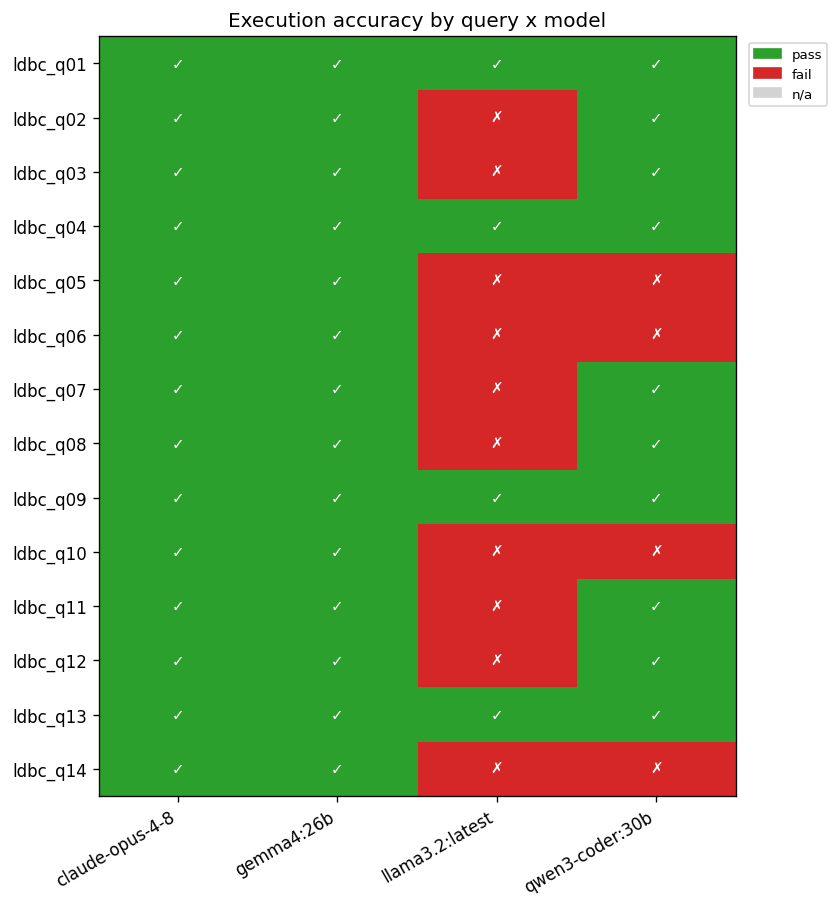

In [7]:
# The all-queries view: per-query outcome for every model, side by side.
p = FIG_DIR / 'query_model_pass.png'
plots.query_model_heatmap(df, 'validation_passed', p, discrete=True, models=MODELS, queries=QUERIES,
                          title='Validation pass by query x model', cbar_label='pass'); plots.show(p)

p = FIG_DIR / 'query_model_f1.png'
plots.query_model_heatmap(df, 'component_f1_overall', p, models=MODELS, queries=QUERIES,
                          title='Component F1 by query x model', cbar_label='F1'); plots.show(p)

if execm is not None and 'execution_accuracy' in df.columns:
    p = FIG_DIR / 'query_model_exec.png'
    plots.query_model_heatmap(df, 'execution_accuracy', p, discrete=True, models=MODELS, queries=QUERIES,
                              title='Execution accuracy by query x model', cbar_label='exec acc'); plots.show(p)

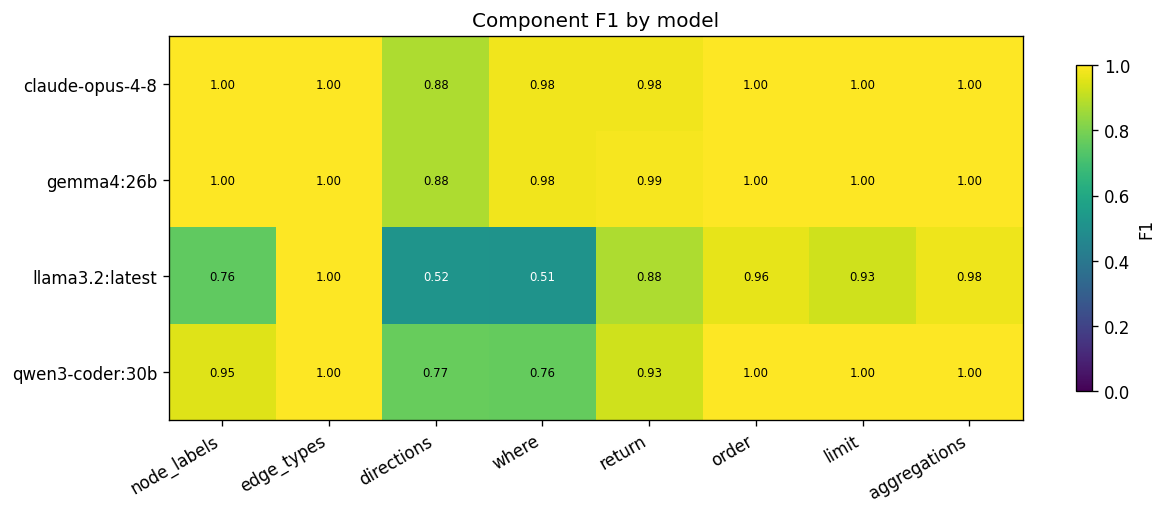

In [8]:
# Where each model is weak: per-clause structural F1, one row per model.
p = FIG_DIR / 'component_f1.png'
plots.component_f1_by_model(df, plots.COMPONENT_F1_COLS, p); plots.show(p)

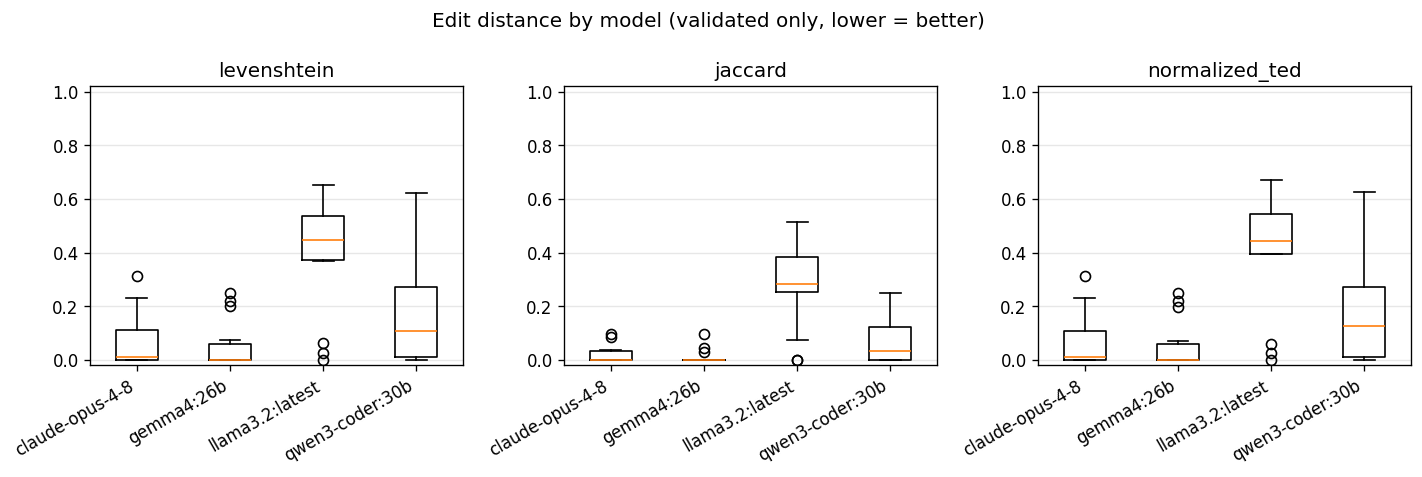

In [9]:
# Edit-distance spread per model (validated translations only, lower = better).
p = FIG_DIR / 'distance_by_model.png'
plots.distance_boxplots(df, p); plots.show(p)

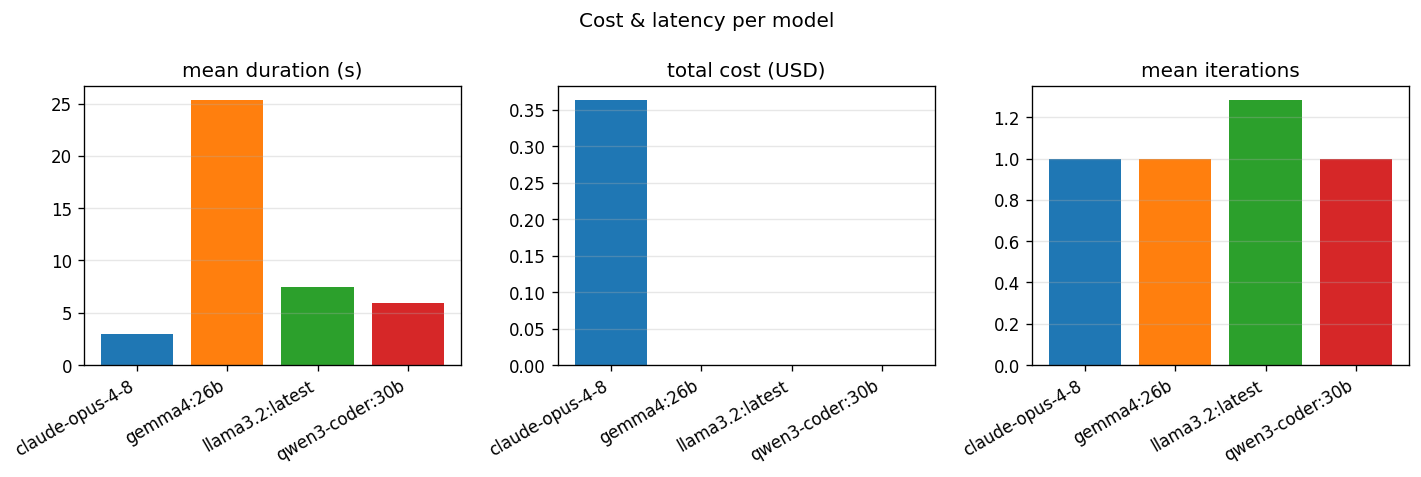

In [10]:
# Operational cost of each model: mean duration, total USD, mean fix iterations.
p = FIG_DIR / 'cost_latency.png'
plots.cost_latency(df, p); plots.show(p)

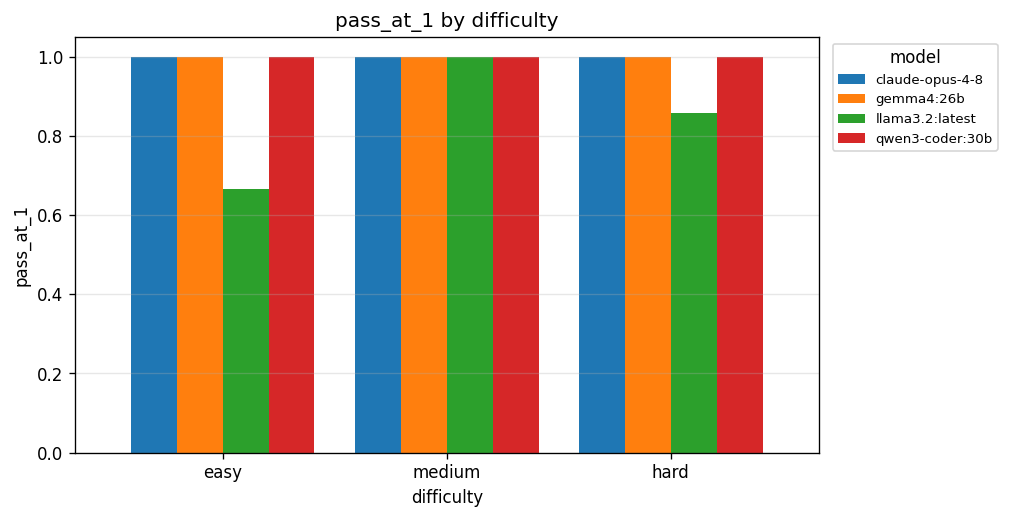

In [11]:
# Does a model degrade on harder queries? Pass@1 by difficulty, grouped by model.
p = FIG_DIR / 'passrate_by_difficulty.png'
plots.passrate_by_difficulty(df, 'pass_at_1', p); plots.show(p)

## Failure list for manual error-taxonomy annotation

In [12]:
failure_mask = ~df['validation_passed'].astype(bool)
if execm is not None and 'execution_accuracy' in df.columns:
    failure_mask = failure_mask | (df['execution_accuracy'].fillna(1.0) < 1.0)
fcols = ['dataset','target','model','query_id','difficulty','validation_passed',
         'component_f1_overall','normalized_ted']
failures = df[failure_mask][fcols].copy()
failures['category'] = ''; failures['notes'] = ''
failures = failures.sort_values(['dataset','target','query_id']).reset_index(drop=True)
print(f'{len(failures)} failure cases to classify.')
failures.head(20)

14 failure cases to classify.


,dataset,target,model,query_id,difficulty,validation_passed,component_f1_overall,normalized_ted,category,notes
0,ldbc,cypher,llama3.2:latest,ldbc_q02,easy,True,0.767045,0.480000,,
1,ldbc,cypher,llama3.2:latest,ldbc_q03,easy,True,0.708333,0.463415,,
2,ldbc,cypher,llama3.2:latest,ldbc_q05,hard,True,0.617029,0.596774,,
3,ldbc,cypher,qwen3-coder:30b,ldbc_q05,hard,True,0.722222,0.625000,,
4,ldbc,cypher,llama3.2:latest,ldbc_q06,medium,True,0.812500,0.392857,,
5,ldbc,cypher,qwen3-coder:30b,ldbc_q06,medium,True,0.975000,0.166667,,
6,ldbc,cypher,llama3.2:latest,ldbc_q07,medium,True,0.827223,0.473118,,
7,ldbc,cypher,llama3.2:latest,ldbc_q08,hard,True,0.664773,0.672269,,
8,ldbc,cypher,llama3.2:latest,ldbc_q10,hard,True,0.896569,0.395833,,
9,ldbc,cypher,qwen3-coder:30b,ldbc_q10,hard,True,0.875000,0.050000,,


## Write the final markdown report

In [13]:
from tabulate import tabulate

def md_table(d, floatfmt='.3f'):
    return tabulate(d.reset_index(), headers='keys', tablefmt='github', floatfmt=floatfmt, showindex=False)

total_records = len(df); validated = int(df['validation_passed'].sum())
total_in = int(df['billed_input_tokens'].sum()) if 'billed_input_tokens' in df.columns else (int(df['input_tokens'].sum()) if 'input_tokens' in df.columns else 0)
total_out = int(df['output_tokens'].sum()) if 'output_tokens' in df.columns else 0
total_cost = float(df['cost_usd'].sum()) if 'cost_usd' in df.columns else 0.0
models = ', '.join(MODELS)

# Per-model tables that back the figures.
comp_by_model = df.groupby('model')[COMP_COLS].mean().reindex(MODELS)
cost_latency_tbl = None
if 'duration_seconds' in df.columns:
    cost_latency_tbl = pd.DataFrame({
        'mean_duration_s': df.groupby('model')['duration_seconds'].mean(),
        'total_cost_usd': df.groupby('model')['cost_usd'].sum(),
        'mean_iterations': df.groupby('model')['iterations_used'].mean(),
    }).reindex(MODELS)

parts = []
parts.append('# rows2graph evaluation report\n')
parts.append(f'Generated: {datetime.now().isoformat(timespec="seconds")}\n')
parts.append(f'Models under evaluation: **{models}**\n')
parts.append(f'Total translations: **{total_records}** ({validated} validated)\n')
parts.append(f'Total tokens: **{total_in:,}** input / **{total_out:,}** output, approx **${total_cost:,.2f}** USD\n')
parts.append('\n## Headline\n'); parts.append(md_table(headline) + '\n')
parts.append('\n## Stratified by dataset x target x model\n'); parts.append(md_table(by_cell) + '\n')
parts.append('\n## Stratified by difficulty\n'); parts.append(md_table(by_diff) + '\n')
parts.append('\n## Component F1 breakdown (per model)\n'); parts.append(md_table(comp_by_model) + '\n')
if cost_latency_tbl is not None:
    parts.append('\n## Cost & latency (per model)\n'); parts.append(md_table(cost_latency_tbl) + '\n')

# Embed only the figures that were actually written; a skipped chart (e.g. the
# execution matrix when notebook 05 did not run) is simply omitted.
figures = [
    ('Per-model headline metrics', 'model_headline.png'),
    ('Pass / fail by query x model', 'query_model_pass.png'),
    ('Component F1 by query x model', 'query_model_f1.png'),
    ('Execution accuracy by query x model', 'query_model_exec.png'),
    ('Component F1 per model', 'component_f1.png'),
    ('Edit distance by model', 'distance_by_model.png'),
    ('Cost & latency per model', 'cost_latency.png'),
    ('Pass rate by difficulty', 'passrate_by_difficulty.png'),
]
parts.append('\n## Figures\n')
for _title, _fn in figures:
    if (FIG_DIR / _fn).exists():
        parts.append(f'![{_title}](figures/{_fn})\n')

parts.append('\n## Error taxonomy (fill in manually)\n')
parts.append('Categories: schema_error, hallucination, direction_error, predicate_error, projection_error, aggregation_error, join_to_path_error, other.\n\n')
parts.append(md_table(failures, floatfmt='.2f') + '\n')
if execm is not None:
    parts.append('\n## Execution-metric caveats\n')
    parts.append('Oracle = gold SQL on Postgres vs generated query on the graph DB (multiset compare).\n\n')
    parts.append('- Date reconciliation: Neo4j stores creationDate/birthday/joinDate as native temporal types (DateTime/Date) while Postgres uses timestamp/date. The comparator canonicalises date columns (identified from the Postgres oracle) to epoch-millis on both sides (Neo4j temporals via .to_native()), so queries that return a date compare correctly.\n')
    parts.append('- Date predicates: with native temporal storage, datetime(...) predicates match, so the former shared q02/q07 failures are resolved. A residual q02 miss for one model comes from translating a timestamp filter with date(...) instead of datetime(...): comparing a datetime property to a date literal returns null in Neo4j (a genuine translation type-mismatch, not a storage artifact).\n')
    parts.append('- Vacuous matches: when both stores return 0 rows, execution_accuracy is 1.0 even if the generated query has a latent bug.\n')
oos = ['- TPC-H, AQL, Gremlin, and additional models (matrix extension points).']
if execm is None:
    oos.insert(0, '- Execution-based metrics (deferred; need graphonauts2 Neo4j + Postgres -- see notebook 05).')
parts.append('\n## Out of scope (this pass)\n')
parts.append('\n'.join(oos) + '\n')
FINAL_MD.write_text('\n'.join(parts))
print(f'Wrote {FINAL_MD}')

Wrote /Users/ivona.obonova/school/rows2graph/rows2graph/evaluation/reports/final.md


In [14]:
print(FINAL_MD.read_text().split('\n## Stratified by dataset', 1)[0])

# rows2graph evaluation report

Generated: 2026-07-01T18:32:47

Models under evaluation: **claude-opus-4-8, gemma4:26b, llama3.2:latest, qwen3-coder:30b**

Total translations: **56** (56 validated)

Total tokens: **206,331** input / **27,837** output, approx **$0.36** USD


## Headline

| dataset   | target   | model           |   validation_pass_rate |   pass@1 |   component_f1 |   normalized_ted |   execution_accuracy |   result_f1 |
|-----------|----------|-----------------|------------------------|----------|----------------|------------------|----------------------|-------------|
| ldbc      | cypher   | claude-opus-4-8 |                  1.000 |    1.000 |          0.979 |            0.071 |                1.000 |       1.000 |
| ldbc      | cypher   | gemma4:26b      |                  1.000 |    1.000 |          0.980 |            0.054 |                1.000 |       1.000 |
| ldbc      | cypher   | llama3.2:latest |                  1.000 |    0.857 |          0.817 |         